In [1]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd
from pandas import Timestamp
# from xarrayutils.plotting import linear_piecewise_scale


In [2]:
# 8 Year
Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975TempOnlyEpochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr'
Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr'

# Repeats
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp no warming
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce30x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp 30 warming 
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce15x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp 15 warming
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce7_5x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth' # temp 7.5 warming

# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce30x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #all warming
# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # all no warming

In [3]:
def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})


    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out

levels = 19
emulation_stability=False
emulation_stability_long=False
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data/", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()


# our groundtruth is always just a time slice of the training (training is a bad name
if emulation_stability:
    # dates = np.array([  3,   8,  13,  18,  23,  28,  33,  38,  43,  48,  53,  58,  63,
    #     68,  73,  78,  83,  88,  93,  98, 103, 108, 113, 118, 123, 128,
    #    133, 138, 143, 148, 153, 158, 163, 168, 173, 178, 183, 188, 193,
    #    198, 203, 208, 213, 218, 223, 228, 233, 238, 243, 248, 253, 258,
    #    263, 268, 273, 278, 283, 288, 293, 298, 303, 308, 313, 318, 323,
       # 328, 333, 338, 343, 348, 353, 358, 363])
    repeats = 100
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = np.array([np.datetime64('1996') + np.timedelta64(day-1,'D') for day in dates])
    for i in range(1,repeats):
        new_time = np.hstack((new_time,np.array([np.datetime64(str(1996+i)) + np.timedelta64(day-1,'D') for day in dates])))
    # new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time[:7300]
    # ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7003))
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 3853))
elif emulation_stability_long:
    repeats = 3000
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = np.arange(ds_groundtruth.time.size*repeats)
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 30000))

else:
    ds_groundtruth = ds_input.sel(time=slice("1975-01-01", None))
    ds_groundtruth = ds_groundtruth.isel(time=slice(2903, 3503)).isel(lev=slice(None, levels))

ls_all = ['uo', 'vo', 'thetao', 'so', 'zos'] #['uo', 'vo', 'thetao', 'so', 'zos'], ['thetao', 'so', 'zos']
ls_temp = ['thetao', 'so', 'zos']
output_folder_all = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_all = os.path.join("./temp", output_folder_all)
output_folder_temp = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_temp = os.path.join("./temp", output_folder_temp)

if os.path.isdir(output_path_all):
    print("Using Output Folder : ", output_path_all)
else:
    print("Using Output Folder : ../outputs")
    output_path_all = "../outputs"

if os.path.isdir(output_path_temp):
    print("Using Output Folder : ", output_path_temp)
else:
    print("Using Output Folder : ../outputs")
    output_path_temp = "../outputs"

ds_prediction_raw_all = xr.open_zarr(Pred_path_all)

ds_prediction_raw_temp = xr.open_zarr(Pred_path_temp)
# if emulation_stability:
#     ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_all_raw.time.size))

# ds_prediction_all = post_processor(
#     ds_prediction_raw_all, ds_groundtruth, ls_all
# )
min_time = min(ds_prediction_raw_all.time.size, min(ds_prediction_raw_temp.time.size, ds_groundtruth.time.size))
ds_prediction_all = post_processor(
    ds_prediction_raw_all.isel(time = slice(0,min_time)), ds_groundtruth.isel(time = slice(0,min_time)), ls_all
)

ds_prediction_temp = post_processor(
    ds_prediction_raw_temp.isel(time = slice(0,min_time)), ds_groundtruth.isel(time = slice(0,min_time)), ls_temp
)


# Run the test to make sure the output is formatted correctly
ds_prediction_all = ds_prediction_all.transpose('time','lev',...)
ds_prediction_temp = ds_prediction_temp.transpose('time','lev',...)
ds_groundtruth = ds_groundtruth.transpose('time','lev',...)

Using Output Folder :  ./temp/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55
Using Output Folder :  ./temp/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55


In [4]:
# ds_prediction_all = ds_prediction_all.isel(time=slice(7000,None))
# ds_prediction_temp = ds_prediction_temp.isel(time=slice(7000,7000+ds_prediction_all.time.size))


In [5]:
ds_prediction_all

<xarray.Dataset>
Dimensions:         (time: 600, y: 180, x: 360, lev: 19, y_b: 181, x_b: 361)
Coordinates:
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * time            (time) object 2014-10-10 12:00:00 ... 2022-12-24 12:00:00
Dimensions without coordinates: y_b, x_b
Data variables:
    uo              (time, lev, y, x) float64 dask.array<chunksize=(75, 10, 23, 45), meta=np.ndarray>
    vo              (time, lev, y, x) float64 dask.array<chunksize=(75, 1, 23, 45), meta=np.ndarray>
    thetao          (time, lev, y, x) float64 dask.array<chunksize=(75, 2, 23, 45), meta=np.ndarray>
    so              (time, lev, y, x) float64 dask.array<chunksize=(75, 3, 23, 45), meta=np.ndarray>
    zos             (time, y, x) float64 dask.array<chunksize=(75, 23, 45), meta=np.ndarray>

In [6]:
ds_prediction_temp

<xarray.Dataset>
Dimensions:         (time: 600, y: 180, x: 360, lev: 19, y_b: 181, x_b: 361)
Coordinates:
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * time            (time) object 2014-10-10 12:00:00 ... 2022-12-24 12:00:00
Dimensions without coordinates: y_b, x_b
Data variables:
    thetao          (time, lev, y, x) float64 dask.array<chunksize=(75, 10, 23, 45), meta=np.ndarray>
    so              (time, lev, y, x) float64 dask.array<chunksize=(75, 1, 23, 45), meta=np.ndarray>
    zos             (time, y, x) float64 dask.array<chunksize=(75, 23, 45), meta=np.ndarray>

In [7]:
ds_prediction_all['y']  = ds_prediction_all.y.assign_attrs(long_name='latitude')
ds_prediction_all['x']  = ds_prediction_all.x.assign_attrs(long_name='longitude')
ds_prediction_all['thetao'] = ds_prediction_all['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")
ds_prediction_all['zos'] = ds_prediction_all['zos'].assign_attrs(long_name = r"SSH", units = r"m")
ds_prediction_all['uo'] = ds_prediction_all['uo'].assign_attrs(long_name = r"${u}$", units = r"m/s")
ds_prediction_all['vo'] = ds_prediction_all['vo'].assign_attrs(long_name = r"${v}$", units = r"m/s")

ds_prediction_temp['y']  = ds_prediction_temp.y.assign_attrs(long_name='latitude')
ds_prediction_temp['x']  = ds_prediction_temp.x.assign_attrs(long_name='longitude')
ds_prediction_temp['thetao'] = ds_prediction_temp['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")
ds_prediction_temp['zos'] = ds_prediction_temp['zos'].assign_attrs(long_name = r"SSH", units = r"m")

ds_groundtruth['y']  = ds_groundtruth.y.assign_attrs(long_name='latitude')
ds_groundtruth['x']  = ds_groundtruth.x.assign_attrs(long_name='longitude')
ds_groundtruth['thetao'] = ds_groundtruth['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")
ds_groundtruth['zos'] = ds_groundtruth['zos'].assign_attrs(long_name = r"SSH", units = r"m")
ds_groundtruth['uo'] = ds_groundtruth['uo'].assign_attrs(long_name = r"${u}$", units = r"m/s")
ds_groundtruth['vo'] = ds_groundtruth['vo'].assign_attrs(long_name = r"${v}$", units = r"m/s")

In [8]:
def remove_climatology(ds, var='zos'):
    ssh = ds[var].copy()
    
    # Compute the climatology
    climatology = ssh.groupby('time.dayofyear').mean('time').compute()

    # Remove the seasonal cycle 
    day_of_year = ssh['time'].dt.dayofyear
    ssh = ds[var] - climatology.sel(dayofyear=day_of_year)
    
    # ssh = (ssh*ds.areacello).sum(["x","y"])/ds.areacello.sum(["x","y"])
    return ssh.compute(), climatology

In [67]:
%%time
ssh_groundtruth, clim_groundtruth = remove_climatology(ds_groundtruth)

<xarray.DataArray 'zos' (dayofyear: 73, y: 180, x: 360)>
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.5931485 , -0.5932847 , -0.5934629 , ..., -0.59267515,
         -0.59281063, -0.5929723 ],
        [-0.6038809 , -0.60420424, -0.60452956, ..., -0.6027191 ,
         -0.60311687, -0.6035073 ],
        [-0.5975671 , -0.5979968 , -0.5983867 , ..., -0.5962213 ,
         -0.5967091 , -0.5971469 ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
      

In [68]:
%%time
ssh_prediction_temp, clim_temp = remove_climatology(ds_prediction_temp)

<xarray.DataArray 'zos' (dayofyear: 73, y: 180, x: 360)>
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.5617751 , -0.56222999, -0.56122229, ..., -0.55940779,
         -0.56162491, -0.56058323],
        [-0.56658711, -0.56641326, -0.56604476, ..., -0.56346895,
         -0.56835876, -0.5672185 ],
        [-0.54428908, -0.54297235, -0.54731778, ..., -0.54490826,
         -0.54489367, -0.5468757 ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
      

In [69]:
%%time
ssh_prediction_all, clim_all = remove_climatology(ds_prediction_all)

<xarray.DataArray 'zos' (dayofyear: 73, y: 180, x: 360)>
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.50216669, -0.499988  , -0.49937066, ..., -0.49843252,
         -0.50010715, -0.5039726 ],
        [-0.52624036, -0.52580095, -0.52653269, ..., -0.52852226,
         -0.53325997, -0.53199659],
        [-0.53523634, -0.53574561, -0.53358844, ..., -0.53192976,
         -0.53397662, -0.53440246]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
      

/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


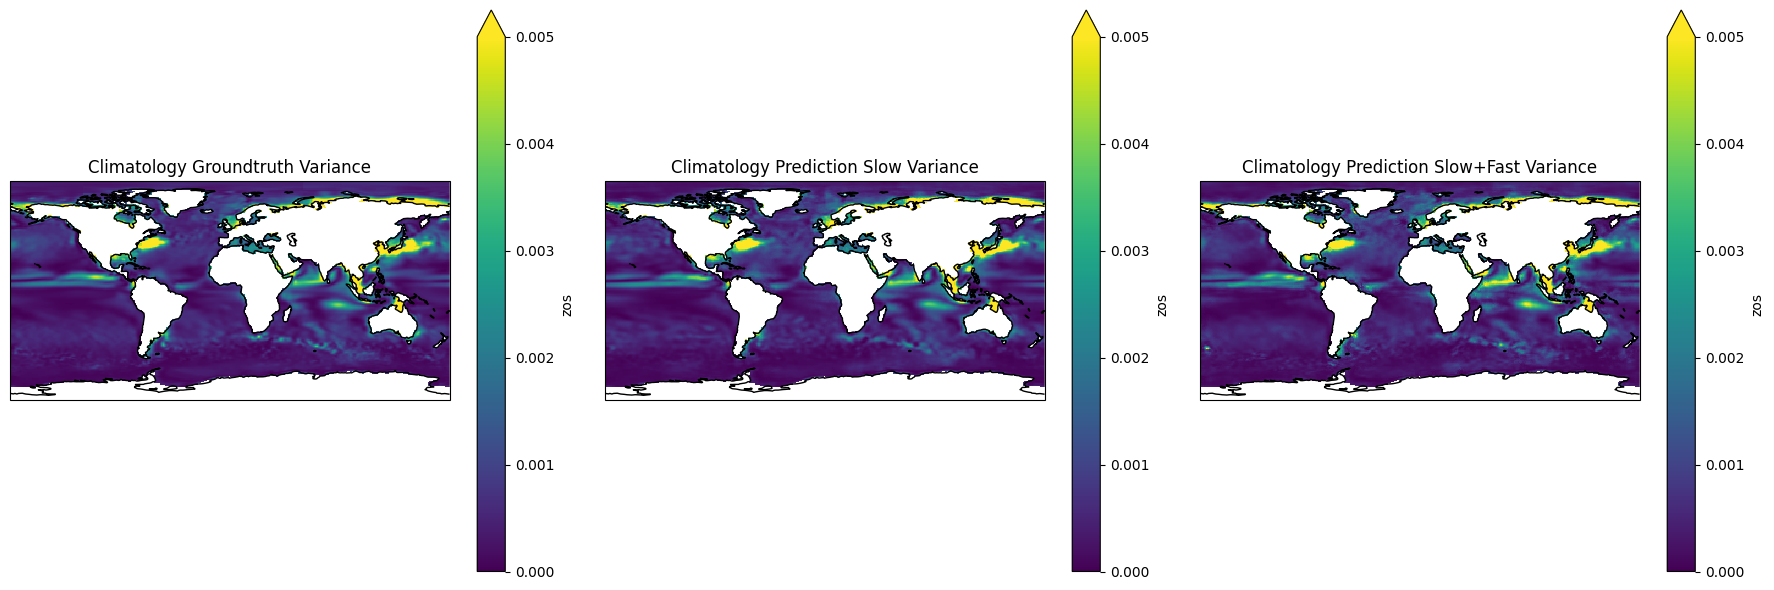

In [72]:
# Define a much smaller range for the colorbar (adjust vmin and vmax to the desired shorter range)
vmin = 0  # Set to the minimum or slightly above if needed
vmax = 0.005  # This is an example of a much smaller range; adjust it to suit your data

fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Compute and plot the variance of clim_groundtruth over dayofyear with the reduced colorbar range
clim_groundtruth.var('dayofyear').plot(ax=axs[0], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].set_title('Climatology Groundtruth Variance')
axs[0].coastlines()

# Compute and plot the variance of clim_temp over dayofyear with the reduced colorbar range
clim_temp.var('dayofyear').plot(ax=axs[1], cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title('Climatology Prediction Slow Variance')
axs[1].coastlines()

# Compute and plot the variance of clim_all over dayofyear with the reduced colorbar range
clim_all.var('dayofyear').plot(ax=axs[2], cmap='viridis', vmin=vmin, vmax=vmax)
axs[2].set_title('Climatology Prediction Slow+Fast Variance')
axs[2].coastlines()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


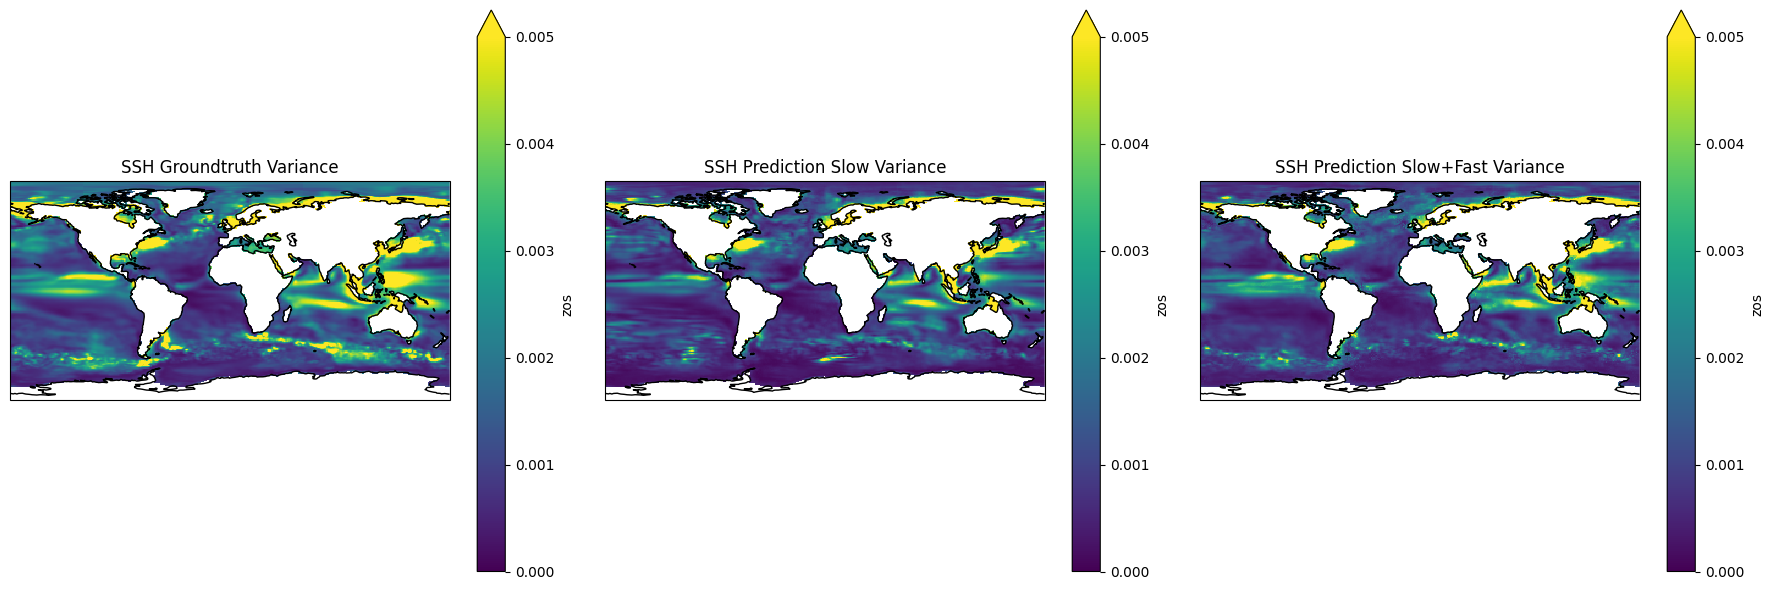

In [63]:
# Define a much smaller range for the colorbar (adjust vmin and vmax to the desired shorter range)
vmin = 0  # Set to the minimum or slightly above if needed
vmax = 0.005  # This is an example of a much smaller range; adjust it to suit your data

fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Compute and plot the variance of ds_groundtruth['zos'] over time with the reduced colorbar range
ds_groundtruth['zos'].var('time').plot(ax=axs[0], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].set_title('SSH Groundtruth Variance')
axs[0].coastlines()

# Compute and plot the variance of ds_prediction_temp['zos'] over time with the reduced colorbar range
ds_prediction_temp['zos'].var('time').plot(ax=axs[1], cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title('SSH Prediction Slow Variance')
axs[1].coastlines()

# Compute and plot the variance of ds_prediction_all['zos'] over time with the reduced colorbar range
ds_prediction_all['zos'].var('time').plot(ax=axs[2], cmap='viridis', vmin=vmin, vmax=vmax)
axs[2].set_title('SSH Prediction Slow+Fast Variance')
axs[2].coastlines()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=a

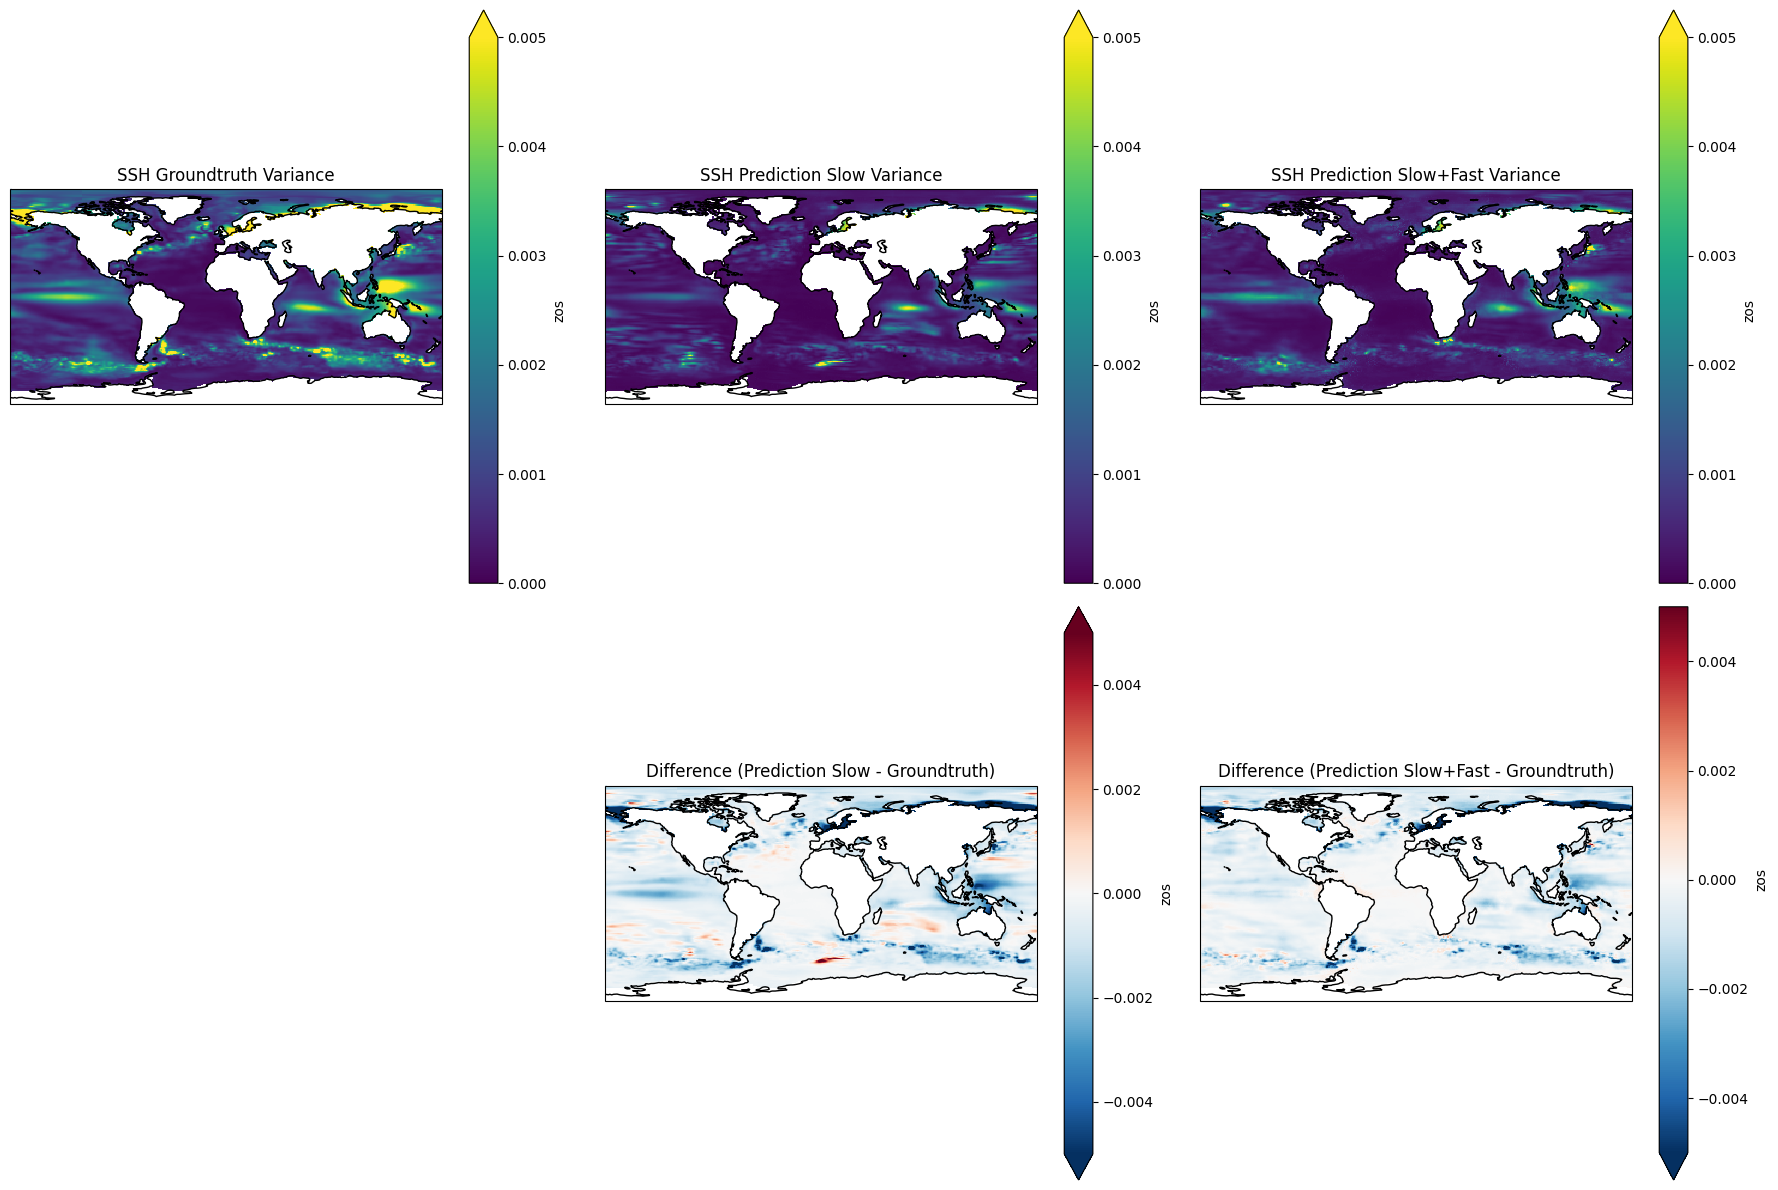

In [78]:
# Define a much smaller range for the colorbar
vmin = 0  # Minimum colorbar value
vmax = 0.005  # Maximum colorbar value

# Define the figure with 3 columns and 2 rows (for the variance and difference plots)
fig, axs = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Row 1 - Variance plots

# Compute and plot the variance of ssh_groundtruth over time with the reduced colorbar range
ssh_groundtruth.var('time').plot(ax=axs[0, 0], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 0].set_title('SSH Groundtruth Variance')
axs[0, 0].coastlines()

# Compute and plot the variance of ssh_prediction_temp over time with the reduced colorbar range
ssh_prediction_temp.var('time').plot(ax=axs[0, 1], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 1].set_title('SSH Prediction Slow Variance')
axs[0, 1].coastlines()

# Compute and plot the variance of ssh_prediction_all over time with the reduced colorbar range
ssh_prediction_all.var('time').plot(ax=axs[0, 2], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 2].set_title('SSH Prediction Slow+Fast Variance')
axs[0, 2].coastlines()

# Row 2 - Difference plots

# Compute and plot the difference: ssh_groundtruth - ssh_prediction_temp
(ssh_prediction_temp.var('time') - ssh_groundtruth.var('time')).plot(ax=axs[1, 1], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axs[1, 1].set_title('Difference (Prediction Slow - Groundtruth)')
axs[1, 1].coastlines()

# Compute and plot the difference: ssh_groundtruth - ssh_prediction_all
(ssh_prediction_all.var('time') - ssh_groundtruth.var('time')).plot(ax=axs[1, 2], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axs[1, 2].set_title('Difference (Prediction Slow+Fast - Groundtruth)')
axs[1, 2].coastlines()

# Remove the first column in the second row (to keep the layout clean)
axs[1, 0].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

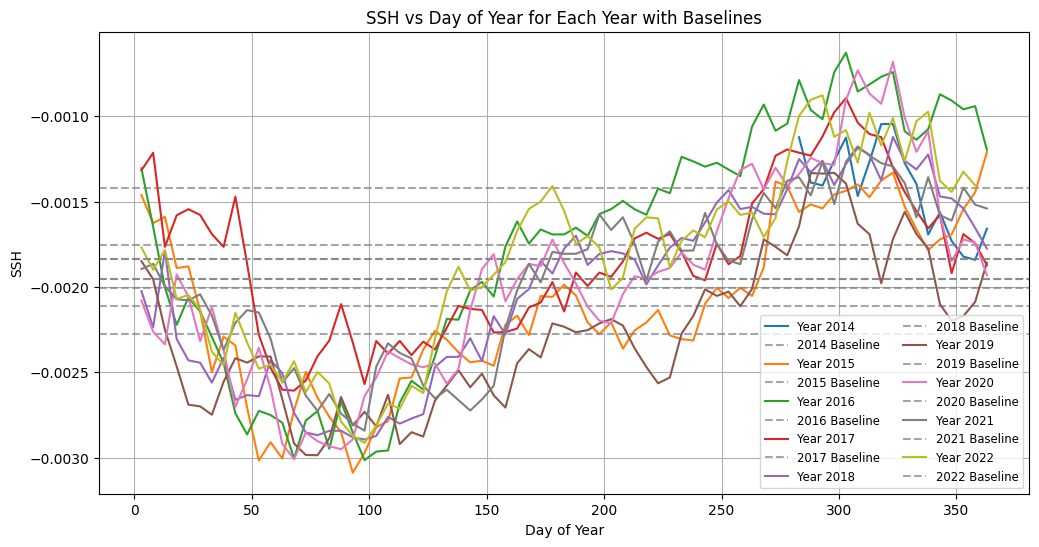

In [38]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# First group by year and yearday
global_average_ssh = ((ds_groundtruth['zos']*ds_groundtruth.areacello).sum(["x","y"])/ds_groundtruth.areacello.sum(["x","y"])).compute()
ssh_by_year = global_average_ssh.groupby('time.year')
ssh_by_yearday = global_average_ssh.groupby('time.dayofyear')

# Set up the plot
plt.figure(figsize=(12, 6))

# Iterate over each year group and plot
for year, data in ssh_by_year:
    # Extract day of year and corresponding SSH anomalies
    yearday = data['time'].dt.dayofyear
    ssh_values = data.values
    
    # Plot the SSH anomalies against yearday for the current year
    plt.plot(yearday, ssh_values, label=f'Year {year}')
    
    # Compute the yearly mean (baseline) and plot as a horizontal line
    yearly_mean = ssh_values.mean()
    plt.axhline(y=yearly_mean, color='gray', linestyle='--', alpha=0.7, label=f'{year} Baseline')

plt.xlabel('Day of Year')
plt.ylabel('SSH')
plt.title('SSH vs Day of Year for Each Year with Baselines')
plt.legend(loc='best', fontsize='small', ncol=2)
plt.grid(True)
plt.show()

In [117]:
color_1 = '#DE3A41'
color_2 = '#277DC7'

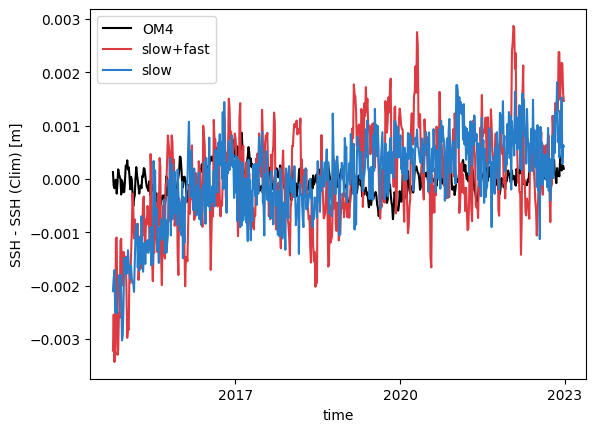

In [118]:
ssh_groundtruth = ssh_groundtruth.rename('SSH - SSH (Clim)')
ssh_groundtruth = ssh_groundtruth.assign_attrs(units = 'm')
ssh_groundtruth.plot(label="OM4", c='k')

ssh_prediction_all = ssh_prediction_all.rename('SSH - SSH (Clim)')
ssh_prediction_all = ssh_prediction_all.assign_attrs(units = 'm')
ssh_prediction_all.plot(label="slow+fast", c=color_1)

ssh_prediction_temp = ssh_prediction_temp.rename('SSH - SSH (Clim)')
ssh_prediction_temp = ssh_prediction_temp.assign_attrs(units = 'm')
ssh_prediction_temp.plot(label="slow", c=color_2)

plt.legend()
plt.show()

In [9]:
sst_groundtruth, _ = remove_climatology(ds_groundtruth.isel(lev=0), 'thetao')
sst_prediction_temp, _ = remove_climatology(ds_prediction_temp.isel(lev=0), 'thetao')
sst_prediction_all, _ = remove_climatology(ds_prediction_all.isel(lev=0), 'thetao')

<xarray.DataArray 'thetao' (dayofyear: 73, y: 180, x: 360)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.7334474, -1.7339606, -1.7345307, ..., -1.7320318,
         -1.7324579, -1.732934 ],
        [-1.7425435, -1.7430298, -1.74352  , ..., -1.7408862,
         -1.7414427, -1.7419982],
        [-1.7324204, -1.732846 , -1.7332356, ..., -1.7311591,
         -1.7316117, -1.7320237]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [-1.7319088, -1.7324159, -1.7329793, ..., -1.7304

/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=a

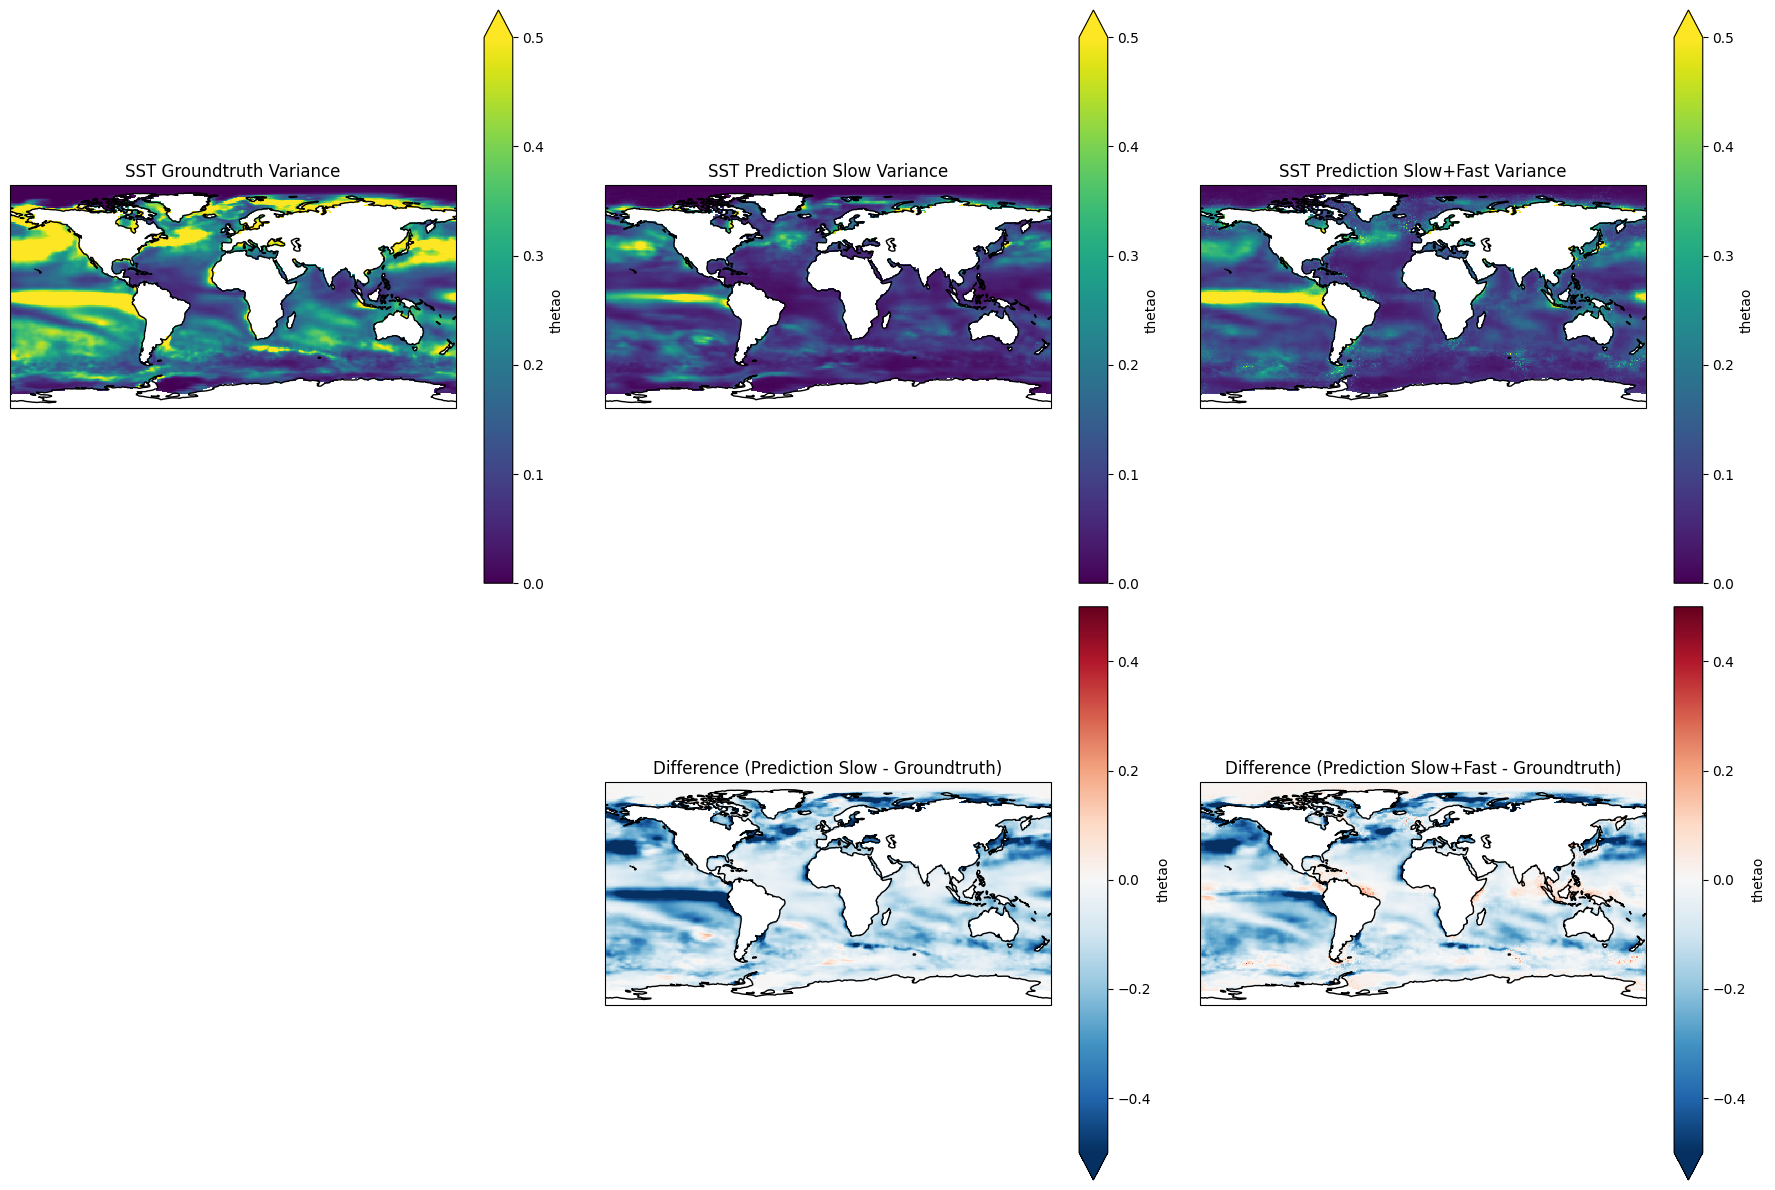

In [14]:
# Define a much smaller range for the colorbar
vmin = 0  # Minimum colorbar value
vmax = 0.5  # Maximum colorbar value

# Define the figure with 3 columns and 2 rows (for the variance and difference plots)
fig, axs = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Row 1 - Variance plots

# Compute and plot the variance of sst_groundtruth over time with the reduced colorbar range
sst_groundtruth.var('time').plot(ax=axs[0, 0], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 0].set_title('SST Groundtruth Variance')
axs[0, 0].coastlines()

# Compute and plot the variance of sst_prediction_temp over time with the reduced colorbar range
sst_prediction_temp.var('time').plot(ax=axs[0, 1], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 1].set_title('SST Prediction Slow Variance')
axs[0, 1].coastlines()

# Compute and plot the variance of sst_prediction_all over time with the reduced colorbar range
sst_prediction_all.var('time').plot(ax=axs[0, 2], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 2].set_title('SST Prediction Slow+Fast Variance')
axs[0, 2].coastlines()

# Row 2 - Difference plots

# Compute and plot the difference: sst_groundtruth - sst_prediction_temp
(sst_prediction_temp.var('time') - sst_groundtruth.var('time')).plot(ax=axs[1, 1], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axs[1, 1].set_title('Difference (Prediction Slow - Groundtruth)')
axs[1, 1].coastlines()

# Compute and plot the difference: sst_groundtruth - sst_prediction_all
(sst_prediction_all.var('time') - sst_groundtruth.var('time')).plot(ax=axs[1, 2], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axs[1, 2].set_title('Difference (Prediction Slow+Fast - Groundtruth)')
axs[1, 2].coastlines()

# Remove the first column in the second row (to keep the layout clean)
axs[1, 0].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

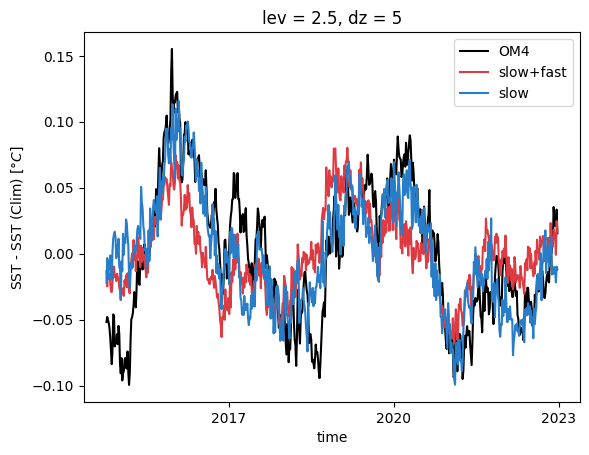

In [126]:
sst_groundtruth = sst_groundtruth.rename('SST - SST (Clim)')
sst_groundtruth = sst_groundtruth.assign_attrs(units = r'$\degree C$')
sst_groundtruth.plot(label="OM4", c='k')

sst_prediction_temp = sst_prediction_temp.rename('SST - SST (Clim)')
sst_prediction_temp = sst_prediction_temp.assign_attrs(units = r'$\degree C$')
sst_prediction_temp.plot(label="slow+fast", c=color_1)

sst_prediction_all = sst_prediction_all.rename('SST - SST (Clim)')
sst_prediction_all = sst_prediction_all.assign_attrs(units = r'$\degree C$')
sst_prediction_all.plot(label="slow", c=color_2)

plt.legend()
plt.show()

In [118]:
# # Compute Basin Heat Content Time Series
# Days_to_Eq = 1000

# basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

# mask = merged_mask(basins,ds_prediction_all.drop_vars(['lat','lon']))

# atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
# pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
# southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
# indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

# masks = atlantic_mask.to_dataset(name='Atlantic')
# masks['Pacific']  = pacific_mask
# masks['Southern'] = southern_ocean_mask
# masks['Indian'] = indian_ocean_mask

# c_p = 3850 #J/(kg C) 
# rho_0 = 1025 #kg/m^3

# fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
# ax_flat = ax.flatten()

# for i, var in enumerate(list(masks.keys())):
#     OHC_pred = ((ds_prediction_all['thetao']*c_p*rho_0*masks[var])*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev'])    
#     OHC_pred.plot(ax = ax_flat[i], label = 'Slow + Fast', c = 'r')

#     OHC_pred_temp = ((ds_prediction_temp['thetao']*c_p*rho_0*masks[var])*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev'])    
#     OHC_pred_temp.plot(ax = ax_flat[i], label = 'Slow', c = 'b')
    
#     ax_flat[i].legend()
#     ax_flat[i].set_title("Heat Content " + var + " Ocean")
#     coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[Days_to_Eq:].size), OHC_pred[Days_to_Eq:], 1)
#     ax_flat[i].plot(OHC_pred[Days_to_Eq:].time.data, np.arange(OHC_pred[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')
    
#     coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_temp[Days_to_Eq:].size), OHC_pred_temp[Days_to_Eq:], 1)
#     ax_flat[i].plot(OHC_pred_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')

# # plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Basins_OHC_Salinity_Long.png", bbox_inches='tight')
# plt.show()

/state/partition1/job-51088952/ipykernel_2491860/3188380482.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
/state/partition1/job-51088952/ipykernel_2491860/3188380482.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)
/state/partition1/job-51088952/ipykernel_2491860/3188380482.py:73: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)


OHC portion of upper trend: -0.05
OHC portion of mid trend: 0.85
OHC portion of deep trend: 0.20


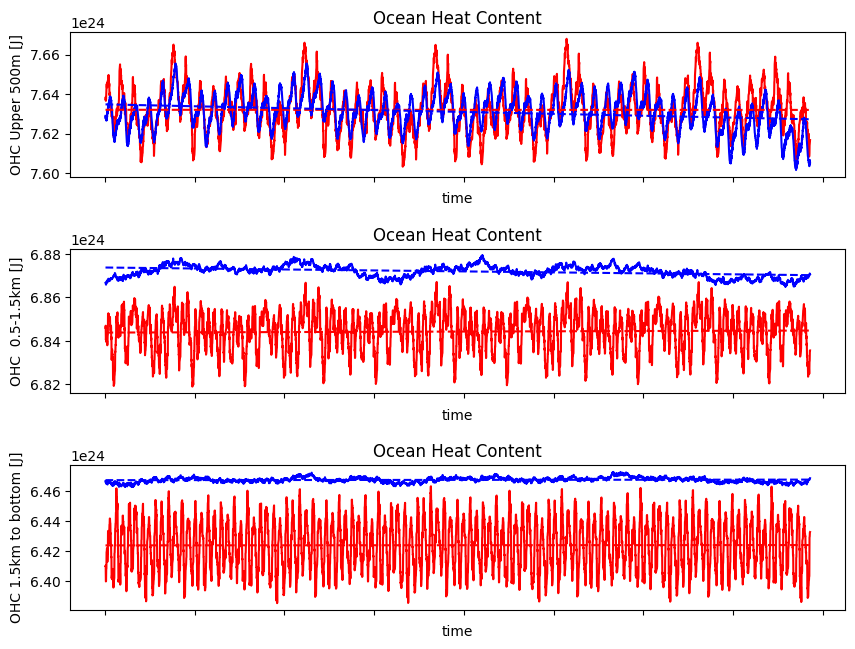

In [106]:
# Compute Basin Heat Content Time Series

Days_to_Eq = 0
c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(3,1,figsize=(10,7.5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred_upper = ((ds_prediction_all['thetao'].sel(lev = slice(0,500))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()    
OHC_pred_upper = OHC_pred_upper.rename('OHC Upper 500m')
OHC_pred_upper = OHC_pred_upper.assign_attrs(units = 'J')

OHC_pred_upper.plot(ax = ax[0], label = 'slow + fast', c = 'r')

OHC_pred_upper_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(0,500))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute() 
OHC_pred_upper_temp = OHC_pred_upper_temp.rename('OHC Upper 500m')
OHC_pred_upper_temp = OHC_pred_upper_temp.assign_attrs(units = 'J')

OHC_pred_upper_temp.plot(ax = ax[0], label = 'slow', c = 'b')

# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_upper[Days_to_Eq:].size), OHC_pred_upper[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper[Days_to_Eq:].time.data, np.arange(OHC_pred_upper[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_upper_temp[Days_to_Eq:].size), OHC_pred_upper_temp[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')
ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
upper_trend = coeffs_OHC_pred_trend[0]*73
# ax[0].annotate(f'OHC trend: {upper_trend:.2f} j/year',xy = (.25,.75), xycoords='figure fraction',
#             horizontalalignment='left', verticalalignment='top')

OHC_pred_mid = ((ds_prediction_all['thetao'].sel(lev = slice(500,1500))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
OHC_pred_mid = OHC_pred_mid.rename('OHC  0.5-1.5km')
OHC_pred_mid = OHC_pred_mid.assign_attrs(units = 'J')

OHC_pred_mid.plot(ax = ax[1], label = 'slow + fast', c = 'r')

OHC_pred_mid_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(500,1500))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()    
OHC_pred_mid_temp = OHC_pred_mid_temp.rename('OHC  0.5-1.5km')
OHC_pred_mid_temp = OHC_pred_mid_temp.assign_attrs(units = 'J')

OHC_pred_mid_temp.plot(ax = ax[1], label = 'slow', c = 'b')

# ax[0].legend()
ax[1].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_mid[Days_to_Eq:].size), OHC_pred_mid[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid[Days_to_Eq:].time.data, np.arange(OHC_pred_mid[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_mid_temp[Days_to_Eq:].size), OHC_pred_mid_temp[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')
ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)

mid_trend = coeffs_OHC_pred_trend[0]*73


OHC_pred_deep = ((ds_prediction_all['thetao'].sel(lev = slice(1500,None))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep = OHC_pred_deep.rename('OHC 1.5km to bottom')
OHC_pred_deep = OHC_pred_deep.assign_attrs(units = 'J')

OHC_pred_deep.plot(ax = ax[2], label = 'slow + fast', c = 'r')

OHC_pred_deep_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(1500,None))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep_temp = OHC_pred_deep_temp.rename('OHC 1.5km to bottom')
OHC_pred_deep_temp = OHC_pred_deep_temp.assign_attrs(units = 'J')

OHC_pred_deep_temp.plot(ax = ax[2], label = 'slow', c = 'b')

# ax[0].legend()
ax[2].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_deep[Days_to_Eq:].size), OHC_pred_deep[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep[Days_to_Eq:].time.data, np.arange(OHC_pred_deep[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_deep_temp[Days_to_Eq:].size), OHC_pred_deep_temp[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')
ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)

deep_trend = coeffs_OHC_pred_trend[0]*73

total_trend = upper_trend + mid_trend + deep_trend
print(f'OHC portion of upper trend: {upper_trend/total_trend:.2f}')
print(f'OHC portion of mid trend: {mid_trend/total_trend:.2f}')
print(f'OHC portion of deep trend: {deep_trend/total_trend:.2f}')

# plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Depth_OHC_Long_Warming.png", bbox_inches='tight')
plt.show()


0.0202649684023305
-0.0021827701449634715


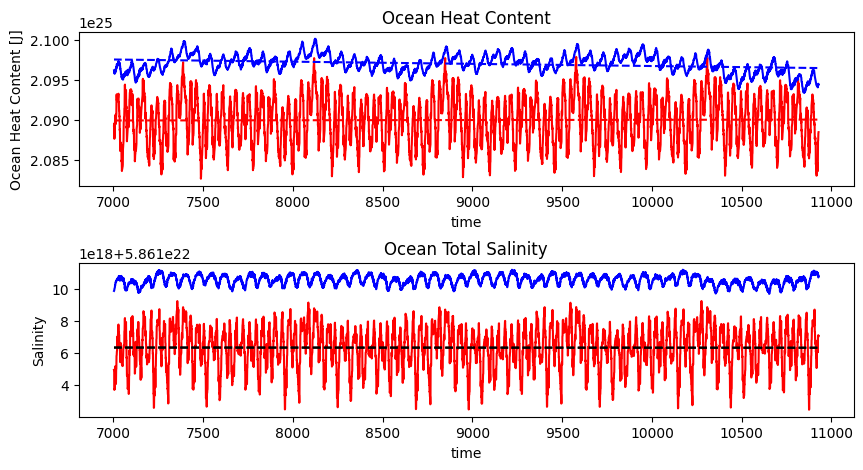

In [107]:
Days_to_Eq = 0

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,1,figsize=(10,5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred = ((ds_prediction_all['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
OHC_pred = OHC_pred.rename('Ocean Heat Content')
OHC_pred = OHC_pred.assign_attrs(units = 'J')

OHC_pred.plot(ax = ax[0], label = 'pred', c = 'r')

OHC_pred_temp = ((ds_prediction_temp['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
OHC_pred_temp = OHC_pred_temp.rename('Ocean Heat Content')
OHC_pred_temp = OHC_pred_temp.assign_attrs(units = 'J')

OHC_pred_temp.plot(ax = ax[0], label = 'Slow', c = 'b')

# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[:].size), OHC_pred[:], 1)
ax[0].plot(OHC_pred[:].time.data, np.arange(OHC_pred[:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = 'r', ls = '--')
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_temp[:].size), OHC_pred_temp[:], 1)
ax[0].plot(OHC_pred_temp[:].time.data, np.arange(OHC_pred_temp[:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = 'b', ls = '--')

salinity = ((ds_prediction_all['so'][Days_to_Eq:]*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
salinity = salinity.rename('Salinity')
salinity = salinity.assign_attrs(units = 'g')

salinity.plot(ax = ax[1], label = 'slow + fast', c = 'r')

salinity_temp = ((ds_prediction_temp['so'][Days_to_Eq:]*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
salinity_temp = salinity_temp.rename('Salinity')
salinity_temp_temp = salinity_temp.assign_attrs(units = 'g')

salinity_temp.plot(ax = ax[1], label = 'slow', c = 'b')

# ax[1].legend()
ax[1].set_title("Ocean Total Salinity")
coeffs_salinity_trend= np.polyfit(np.arange(salinity[:].size), salinity[:], 1)
ax[1].plot(salinity[:].time.data, np.arange(salinity[:].size)*coeffs_salinity_trend[0] + coeffs_salinity_trend[1],c = 'k', ls = '--')

coeffs_salinity_trend= np.polyfit(np.arange(salinity[:].size), salinity[:], 1)
ax[1].plot(salinity[:].time.data, np.arange(salinity[:].size)*coeffs_salinity_trend[0] + coeffs_salinity_trend[1],c = 'k', ls = '--')
print(coeffs_OHC_pred_trend[0]*73/1e21)

print(coeffs_salinity_trend[0]*73/1e17)
# plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Depth_OHC_Salinity_Long_Warming.png", bbox_inches='tight')
plt.show()


In [ ]:
hfs_true = xr.open_zarr("/pscratch/sd/s/suryad/data/OM4_5daily_v0.2.1.zarr").drop_vars(['lon','lat'])['hfds']
hfs_true = hfs_true.sel(time = slice('1990-01-01','1999-12-31')).transpose('time',...)
hfs_true =  xr.concat([hfs_true] * repeats, dim="time")

Text(0.5, 0.98, 'Depth Profiles')

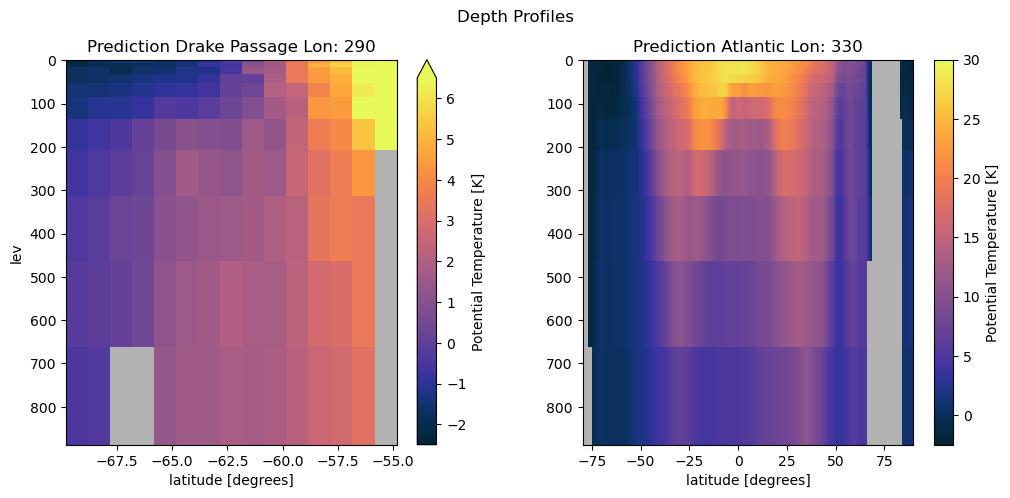

In [15]:
#Drake Passage Full Depth 

new_cmap = cm.cm.thermal 
# new_cmap = cm.cm.balance 

new_cmap.set_bad('grey',.6)

day_start = -100
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)}}
surface = True

fig, ax = plt.subplots(1,2,figsize=(12,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1], 'wspace': 0.25,'hspace':.5})
bounds = regions['Drake Passage']
var = 'thetao'
if surface:
    level_slice = slice(0,1000)
else:
    level_slice = slice(None)

depth_slice = ds_prediction_all[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
depth_slice = depth_slice.assign_attrs(long_name = 'Potential Temperature', units = 'K')

pred_plot = depth_slice.plot(y = 'lev',ax=ax[0],cmap = new_cmap, vmin = -2.5, vmax = 6.5)
ax[0].invert_yaxis()
ax[0].set_title('Prediction Drake Passage Lon: ' +  str(bounds['lon']))

bounds = regions['Atlantic']
depth_slice = ds_prediction_all[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
depth_slice = depth_slice.assign_attrs(long_name = 'Potential Temperature', units = 'K')

pred_plot = depth_slice.plot(y = 'lev',ax=ax[1],cmap = new_cmap, vmin = -2.5, vmax = 30)
ax[1].invert_yaxis()
ax[1].set_ylabel('')
ax[1].set_title('Prediction Atlantic Lon: ' +  str(bounds['lon']))

# fig.subplots_adjust(right=0.825)
# cbar_ax = fig.add_axes([0.85, 0.15, 0.015, 0.7])
# cbar = fig.colorbar(pred_plot, cax=cbar_ax)
# cbar.set_label(var,rotation = 90)
fig.suptitle(r"Depth Profiles" )

Text(0.5, 0.98, 'Depth Profiles')

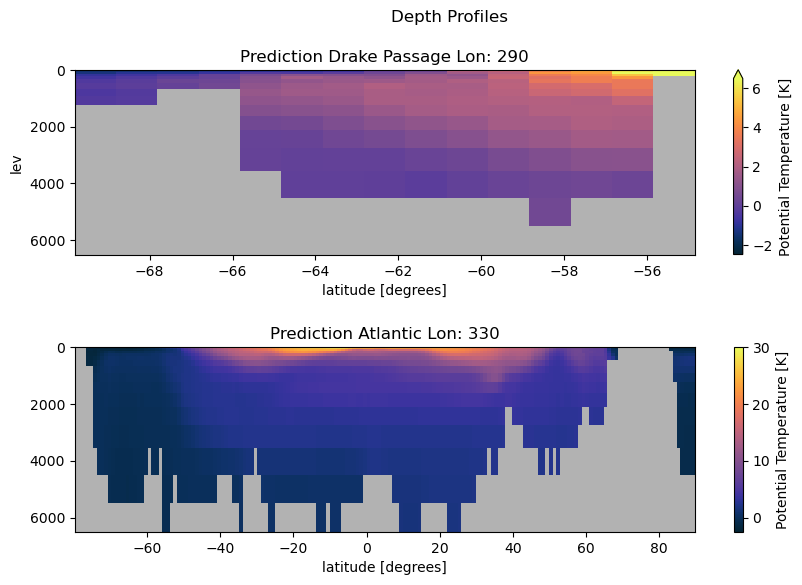

In [16]:
#Drake Passage Full Depth 

new_cmap = cm.cm.thermal 
# new_cmap = cm.cm.balance 

new_cmap.set_bad('grey',.6)

day_start = -100
window = 3
regions = {'Drake Passage': {'lon': 290, 'lat_bnds':slice(-70,-55)},
           'Atlantic': {'lon': 330, 'lat_bnds':slice(-80,90)},
           'Indian': {'lon': 95, 'lat_bnds':slice(-40,20)}}

surface = False

fig, ax = plt.subplots(2,1,figsize=(10,6),gridspec_kw={'width_ratios': [1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
bounds = regions['Drake Passage']
var = 'thetao'
if surface:
    level_slice = slice(0,1000)
else:
    level_slice = slice(None)

depth_slice = ds_prediction_all[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
depth_slice = depth_slice.assign_attrs(long_name = 'Potential Temperature', units = 'K')

pred_plot = depth_slice.plot(y = 'lev',ax=ax[0],cmap = new_cmap, vmin = -2.5, vmax = 6.5)
ax[0].invert_yaxis()
ax[0].set_title('Prediction Drake Passage Lon: ' +  str(bounds['lon']))

bounds = regions['Atlantic']
depth_slice = ds_prediction_all[var].sel(x = bounds['lon'], method = 'nearest').sel(y = bounds['lat_bnds'],lev = level_slice).isel(time = slice(day_start,day_start+window)).mean('time')    
depth_slice = depth_slice.assign_attrs(long_name = 'Potential Temperature', units = 'K')

pred_plot = depth_slice.plot(y = 'lev',ax=ax[1],cmap = new_cmap, vmin = -2.5, vmax = 30)
ax[1].invert_yaxis()
ax[1].set_ylabel('')
ax[1].set_title('Prediction Atlantic Lon: ' +  str(bounds['lon']))

# fig.subplots_adjust(right=0.825)
# cbar_ax = fig.add_axes([0.85, 0.15, 0.015, 0.7])
# cbar = fig.colorbar(pred_plot, cax=cbar_ax)
# cbar.set_label(var,rotation = 90)
fig.suptitle(r"Depth Profiles" )

/global/homes/a/asubel/.conda/envs/NERSC_Kernel/lib/python3.12/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


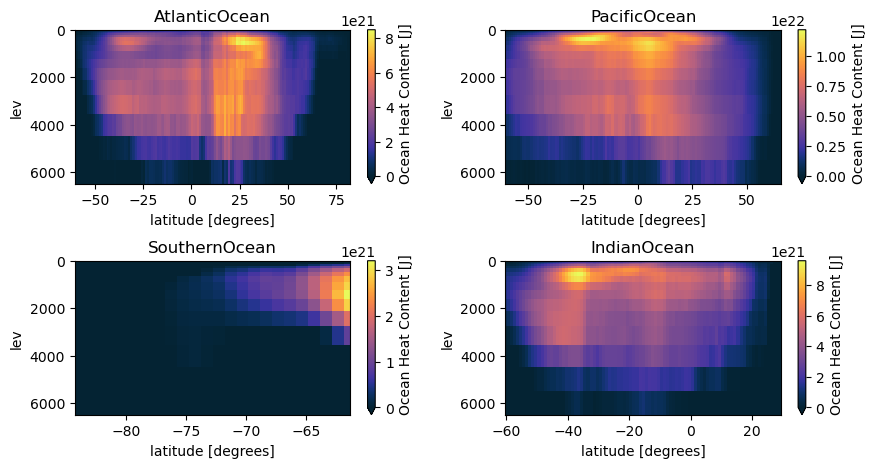

In [15]:
# Compute Basin Heat Content Time Series
new_cmap = cm.cm.thermal 
# new_cmap = cm.cm.balance 

new_cmap.set_bad('grey',.6)

basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

mask = merged_mask(basins,ds_prediction_all.drop_vars(['lat','lon']))

atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

masks = atlantic_mask.to_dataset(name='Atlantic')
masks['Pacific']  = pacific_mask
masks['Southern'] = southern_ocean_mask
masks['Indian'] = indian_ocean_mask

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
ax_flat = ax.flatten()

for i, var in enumerate(list(masks.keys())):
    OHC_pred = ((ds_prediction_all['thetao'].isel(time = slice(-730,None))*c_p*rho_0*masks[var])*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x']).mean('time')    
    OHC_pred = OHC_pred.rename('Ocean Heat Content')
    OHC_pred = OHC_pred.assign_attrs(units = 'J')
    min_lat = OHC_pred.y[np.logical_not(np.isnan(masks[var].mean('x')))][0]
    max_lat = OHC_pred.y[np.logical_not(np.isnan(masks[var].mean('x')))][-1]
    OHC_pred.plot(ax = ax_flat[i],cmap = new_cmap,vmin=0)
    ax_flat[i].set_xlim([min_lat,max_lat])
    ax_flat[i].invert_yaxis()  
    ax_flat[i].set_title(var + 'Ocean')


# fig.savefig('./figures/OHC_Short.png',dpi=250)

In [ ]:
def NinoIndexComputeClim(T,area,dt = 5, window = 150):
    T_clim = T.copy()
    T_clim = T_clim.sel(x = slice(118,260), y = slice(-5,5)).load()
    area = area.sel(x = slice(118,260), y = slice(-5,5))
    clim = T_clim.groupby('time.dayofyear').mean('time').compute()
    window = int(window/dt)
    print(window)
    for i, t in enumerate(T_clim.time.values):
        day = int(Timestamp(t).dayofyear)
        T_clim[i] = (T[i]-clim.sel(dayofyear=day)).data        

    T_clim = T_clim.rolling(time = window).mean()
    T_clim = (T_clim*area).sum(["x","y"])/area.sum(["x","y"])

    return T_clim[window:]

In [9]:
clim_pred = ds_prediction_all['thetao'].sel(lev = slice(0,500)).groupby('time.dayofyear').mean().compute()

In [12]:
nino_pred_compute_clim = NinoIndexComputeClim(ds_prediction_all['thetao'][:,0],ds_prediction_all['areacello'])
nino_pred_compute_clim = nino_pred_compute_clim.rename('Nino 3.4')
nino_pred_compute_clim = nino_pred_compute_clim.assign_attrs(units = 'K')

30


In [13]:
day_max = int((np.argwhere(nino_pred_compute_clim.values == np.nanmax(nino_pred_compute_clim.values[-1000:])) + 30).squeeze())
day_min = int((np.argwhere(nino_pred_compute_clim.values == np.nanmin(nino_pred_compute_clim.values[-1000:])) + 30).squeeze())

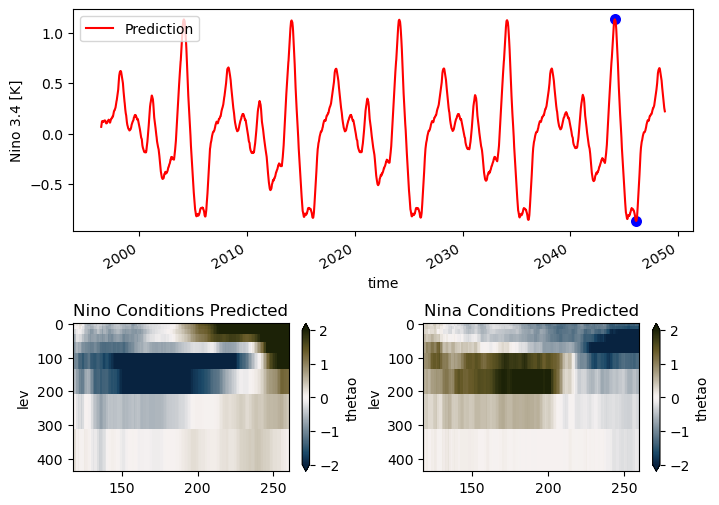

In [14]:

fig,axs = plt.subplot_mosaic([['time series','time series'],['nino_pred','nina_pred']],figsize = (8,6),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.6,.4], 'wspace': 0.3,'hspace':.5})
nino_pred_compute_clim.plot(label = 'Prediction', c = 'r',ax = axs['time series'])
nino_pred_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'b',ax = axs['time series'])
nino_pred_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'b',ax = axs['time series'])
axs['time series'].set_title('')
axs['time series'].legend()
# axs['time series'].set_title('Nino 3.4 Index')

day_start = day_max
window = 3
times = ds_prediction_all['time'][day_start:day_start+window].data

days_of_year = [Timestamp(i).dayofyear for i in times]
pred_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times

tropics_profile_pred = (ds_prediction_all['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])


tropics_profile_pred.plot.pcolormesh(ax = axs['nino_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nino_pred'].set_title('Nino Conditions Predicted')
axs['nino_pred'].set_xlabel('')
axs['nino_pred'].invert_yaxis()


axs['time series'].legend(loc = 'upper left')

day_start = day_min
window = 3
times = ds_prediction_all['time'][day_start:day_start+window].data

days_of_year = [Timestamp(i).dayofyear for i in times]
pred_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times

tropics_profile_pred = (ds_prediction_all['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])


tropics_profile_pred.plot.pcolormesh(ax = axs['nina_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2)
axs['nina_pred'].set_title('Nina Conditions Predicted')
axs['nina_pred'].set_xlabel('')
axs['nina_pred'].invert_yaxis()



In [21]:
fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Nino Long Run.png')